This notebook implements the complete experimental methodology. It covers:
1. Dataset loading and description
2. Data preprocessing
3. Oversampling techniques
4. Ensemble learning models
5. Evaluation metrics
6. Full experimental pipeline

---
## 1. Installation and Imports
Install required libraries and import all necessary modules.

In [ ]:
# Install required libraries
!pip install imbalanced-learn xgboost lightgbm catboost -q

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Oversampling techniques (Section 3.5)
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE
)
from imblearn.combine import SMOTETomek

# Ensemble learning models (Section 3.6)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation metrics (Section 3.7)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression

# Utilities
from collections import Counter
import time

print("All libraries imported successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

All libraries imported successfully!
NumPy: 2.0.2
Pandas: 2.2.2


---
## 2. Dataset Description (Section 3.3)

The dataset used is the **Stroke Prediction Dataset** from Kaggle  
(https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset).

It contains **5,110 patient records** with **11 clinical features** and **1 binary target variable** (`stroke`).

**Features:**
- **Numerical (3):** `age`, `avg_glucose_level`, `bmi`
- **Binary categorical (4):** `gender`, `hypertension`, `heart_disease`, `ever_married`
- **Multi-class categorical (3):** `work_type`, `Residence_type`, `smoking_status`
- **Identifier (1):** `id` (dropped during preprocessing)

In [ ]:
# Load the FULL dataset (5,110 records)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
df.head()

Saving full_filled_stroke_data (1).csv to full_filled_stroke_data (1).csv
Dataset Shape: (201, 11)
Total Records: 201
Total Features: 11


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1


In [ ]:
# Dataset overview
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()
print("\n")
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe(include='all').round(2)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             201 non-null    object 
 1   age                201 non-null    float64
 2   hypertension       201 non-null    int64  
 3   heart_disease      201 non-null    int64  
 4   ever_married       201 non-null    object 
 5   work_type          201 non-null    object 
 6   Residence_type     201 non-null    object 
 7   avg_glucose_level  201 non-null    float64
 8   bmi                201 non-null    float64
 9   smoking_status     201 non-null    object 
 10  stroke             201 non-null    int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 17.4+ KB


DESCRIPTIVE STATISTICS


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,201,201.00,201.00,201.00,201,201,201,201.00,201.00,201,201.0
unique,2,NaN,NaN,NaN,2,4,2,NaN,NaN,4,NaN
top,Male,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,Unknown,NaN
freq,104,NaN,NaN,NaN,149,114,106,NaN,NaN,61,NaN
mean,NaN,52.05,0.23,0.16,NaN,NaN,NaN,126.72,29.34,NaN,0.2
std,NaN,22.28,0.42,0.37,NaN,NaN,NaN,59.24,3.36,NaN,0.4
min,NaN,0.48,0.00,0.00,NaN,NaN,NaN,57.52,17.90,NaN,0.0
25%,NaN,37.00,0.00,0.00,NaN,NaN,NaN,81.43,28.40,NaN,0.0
50%,NaN,58.00,0.00,0.00,NaN,NaN,NaN,99.87,29.95,NaN,0.0
75%,NaN,71.00,0.00,0.00,NaN,NaN,NaN,191.79,31.38,NaN,0.0


In [ ]:
# Table 4.1: Dataset Characteristics and Feature Description
feature_desc = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})
print("Table 4.1: Dataset Characteristics and Feature Description")
feature_desc

Table 4.1: Dataset Characteristics and Feature Description


,Feature,Data Type,Non-Null Count,Missing Values,Unique Values
0,gender,object,201,0,2
1,age,float64,201,0,73
2,hypertension,int64,201,0,2
3,heart_disease,int64,201,0,2
4,ever_married,object,201,0,2
5,work_type,object,201,0,4
6,Residence_type,object,201,0,2
7,avg_glucose_level,float64,201,0,199
8,bmi,float64,201,0,179
9,smoking_status,object,201,0,4


---
## 3. Exploratory Data Analysis (EDA)
Visualizations for Chapter 4 figures.

Class Distribution:
  Non-Stroke (0): 161 (80.10%)
  Stroke (1):     40 (19.90%)
  Imbalance Ratio: 4.0:1


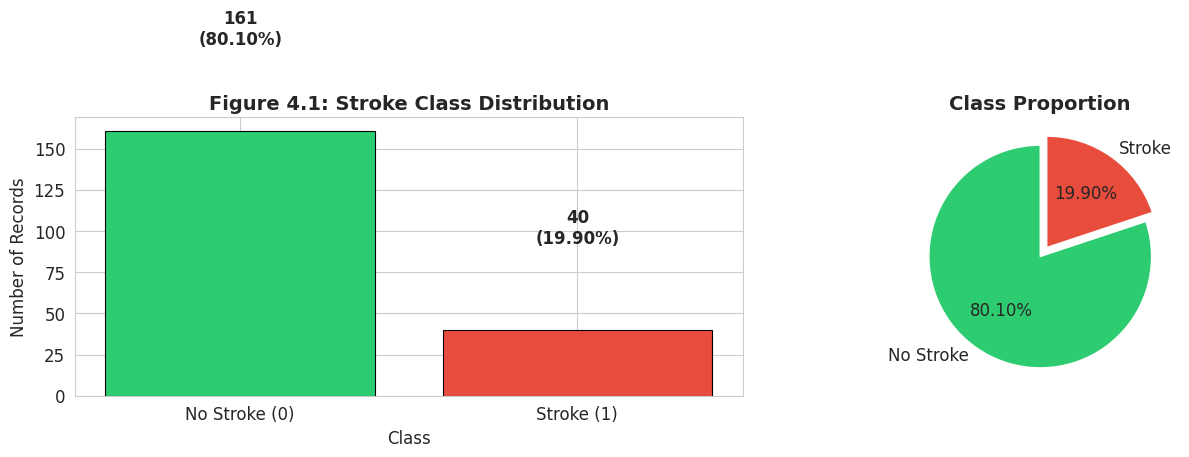

In [ ]:
# ============================================================
# Figure 4.1: Stroke Class Distribution in the Original Dataset
# ============================================================
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Non-Stroke (0): {stroke_counts[0]} ({stroke_pct[0]:.2f}%)")
print(f"  Stroke (1):     {stroke_counts[1]} ({stroke_pct[1]:.2f}%)")
print(f"  Imbalance Ratio: {stroke_counts[0]/stroke_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['No Stroke (0)', 'Stroke (1)'],
                    [stroke_counts[0], stroke_counts[1]],
                    color=colors, edgecolor='black', linewidth=0.8)
for bar, count, pct in zip(bars, stroke_counts.values, stroke_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{count}\n({pct:.2f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Figure 4.1: Stroke Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_xlabel('Class')

# Pie chart
axes[1].pie([stroke_counts[0], stroke_counts[1]],
            labels=['No Stroke', 'Stroke'],
            autopct='%1.2f%%', colors=colors,
            startangle=90, explode=[0, 0.1],
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_4_1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

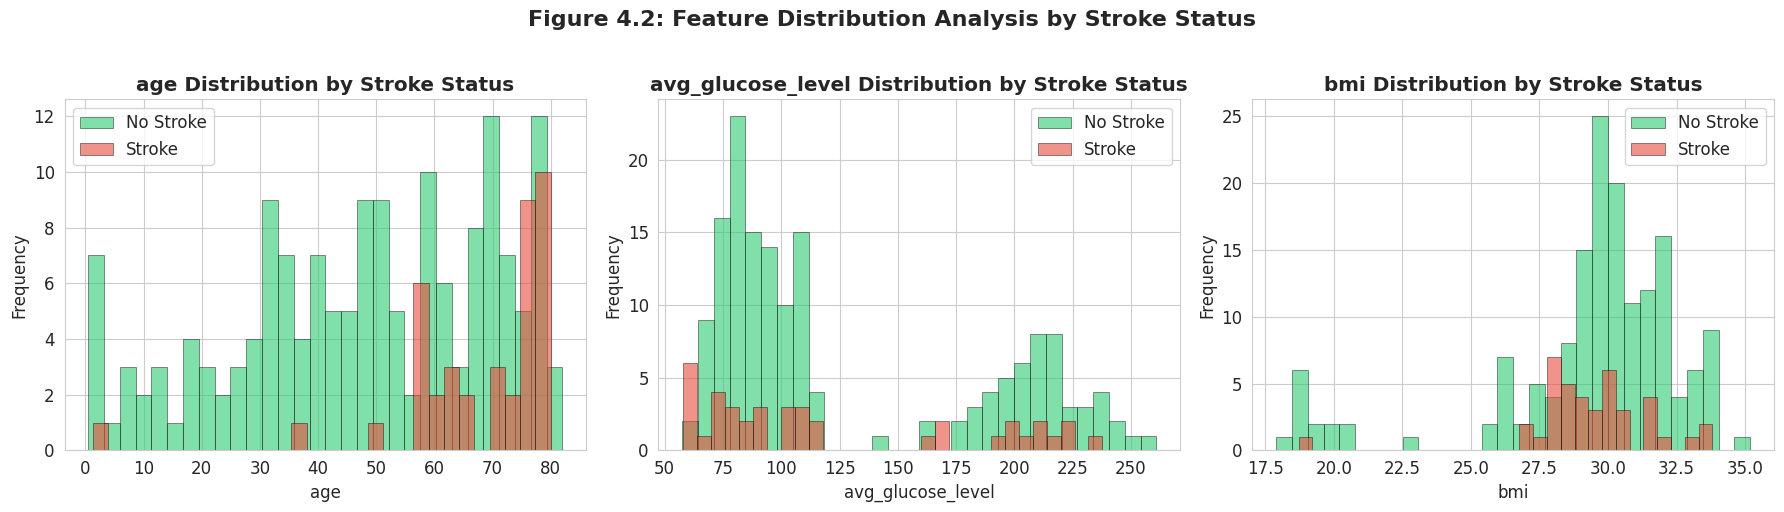

In [ ]:
# ============================================================
# Figure 4.2: Feature Distribution Analysis by Stroke Status
# ============================================================
numerical_features = ['age', 'avg_glucose_level', 'bmi']

# Convert bmi to numeric (handle 'N/A' strings)
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    for label, color, name in [(0, '#2ecc71', 'No Stroke'), (1, '#e74c3c', 'Stroke')]:
        subset = df[df['stroke'] == label][feature].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{feature} Distribution by Stroke Status', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Figure 4.2: Feature Distribution Analysis by Stroke Status',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_4_2_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

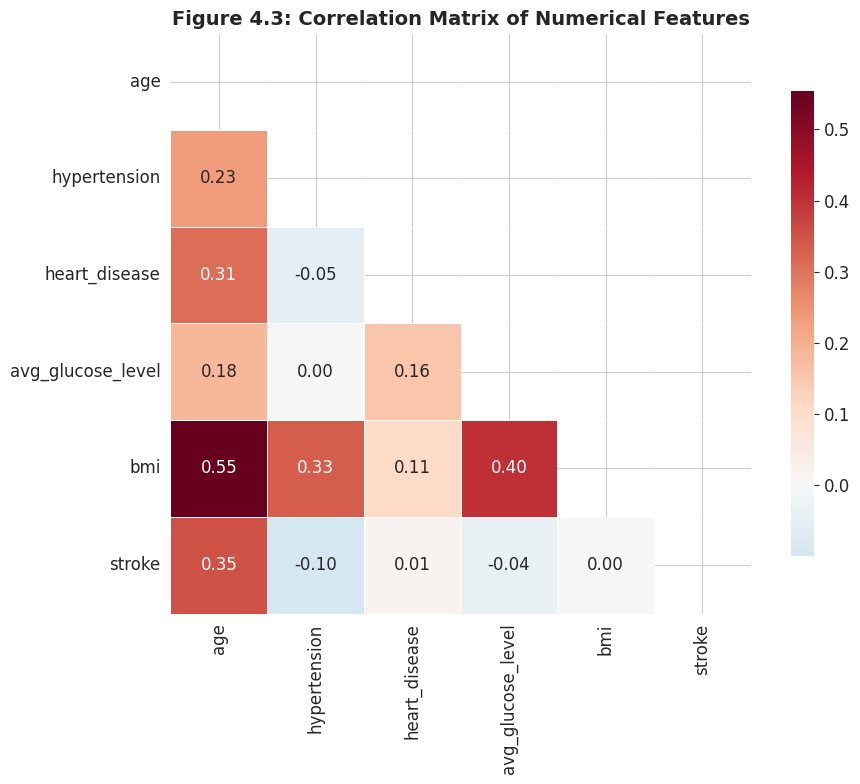


Correlation with Stroke:
stroke               1.000
age                  0.353
heart_disease        0.015
bmi                  0.004
avg_glucose_level   -0.040
hypertension        -0.099
Name: stroke, dtype: float64


In [ ]:
# ============================================================
# Figure 4.3: Correlation Matrix of Numerical Features
# ============================================================
# Encode categorical variables temporarily for correlation
df_corr = df.copy()
df_corr['bmi'] = pd.to_numeric(df_corr['bmi'], errors='coerce')
le_temp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_temp.fit_transform(df_corr[col].astype(str))

# Drop id column
corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Figure 4.3: Correlation Matrix of Numerical Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_4_3_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with Stroke:")
print(corr_matrix['stroke'].sort_values(ascending=False).round(3))

---
## 4. Data Preprocessing (Section 3.4)

Steps:
1. **Section 3.4.1** – Handling missing values (median imputation for BMI)
2. **Section 3.4.2** – Encoding categorical variables (Label Encoding)
3. **Section 3.4.3** – Feature scaling (StandardScaler)
4. **Section 3.4.4** – Train-test split (80/20 stratified)

In [ ]:
# ============================================================
# Section 3.4.1: Handling Missing Values
# ============================================================
print("=" * 60)
print("SECTION 3.4.1: HANDLING MISSING VALUES")
print("=" * 60)

# Make a working copy
data = df.copy()

# Convert bmi to numeric
data['bmi'] = pd.to_numeric(data['bmi'], errors='coerce')

# Check missing values
print("\nMissing values before imputation:")
print(data.isnull().sum())
print(f"\nTotal missing BMI values: {data['bmi'].isnull().sum()}")
print(f"BMI median value: {data['bmi'].median():.2f}")

# Median imputation for BMI (robust to outliers)
bmi_median = data['bmi'].median()
data['bmi'].fillna(bmi_median, inplace=True)

print(f"\nMissing values after imputation:")
print(data.isnull().sum())
print("\n✅ BMI missing values imputed with median.")

SECTION 3.4.1: HANDLING MISSING VALUES

Missing values before imputation:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Total missing BMI values: 0
BMI median value: 29.95

Missing values after imputation:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

✅ BMI missing values imputed with median.


In [ ]:
# Load the FULL dataset (5,110 records)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
df.head()

SECTION 3.4.2: ENCODING CATEGORICAL VARIABLES

Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
  gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
  work_type: {'Govt_job': np.int64(0), 'Private': np.int64(1), 'Self-employed': np.int64(2), 'children': np.int64(3)}
  Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
  smoking_status: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}

✅ All categorical variables encoded using Label Encoding.


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,61.0,0,0,1,2,0,202.21,31.555602,2,1
1,0,59.0,0,0,1,1,0,76.15,30.242937,0,1
2,1,78.0,0,1,1,1,1,219.84,30.698951,0,1
3,1,57.0,0,1,0,0,1,217.08,33.808410,0,1
4,1,58.0,0,0,1,1,0,189.84,31.378534,0,1


In [ ]:
# ============================================================
# Section 3.4.3 & 3.4.4: Feature Scaling and Train-Test Split
# ============================================================
print("=" * 60)
print("SECTION 3.4.3 & 3.4.4: SCALING AND TRAIN-TEST SPLIT")
print("=" * 60)

# Separate features and target
X = data.drop('stroke', axis=1)
y = data['stroke']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Feature names: {X.columns.tolist()}")

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  No Stroke: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.2f}%)")
print(f"  Stroke:    {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.2f}%)")
print(f"\nTest class distribution:")
print(f"  No Stroke: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.2f}%)")
print(f"  Stroke:    {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.2f}%)")

# Feature Scaling (StandardScaler) - applied AFTER split to prevent data leakage
scaler = StandardScaler()
numerical_features = ['age', 'avg_glucose_level', 'bmi']

# Get column indices for numerical features
num_indices = [X_train.columns.get_loc(col) for col in numerical_features]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"\n✅ StandardScaler applied to: {numerical_features}")
print(f"\nScaled training data sample:")
X_train_scaled.head()

SECTION 3.4.3 & 3.4.4: SCALING AND TRAIN-TEST SPLIT

Feature matrix shape: (201, 10)
Target vector shape: (201,)
Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Training set: 160 samples
Test set:     41 samples

Training class distribution:
  No Stroke: 128 (80.00%)
  Stroke:    32 (20.00%)

Test class distribution:
  No Stroke: 33 (80.49%)
  Stroke:    8 (19.51%)

✅ StandardScaler applied to: ['age', 'avg_glucose_level', 'bmi']

Scaled training data sample:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
136,0,0.161159,0,0,1,1,1,-0.344880,0.278256,3
34,1,0.385647,0,1,1,1,1,1.500088,1.149798,0
33,0,1.104006,0,0,0,1,1,-0.718568,-0.345745,0
122,1,1.193801,0,1,1,1,1,1.560845,0.399141,0
39,1,0.834621,1,0,1,2,0,-0.606721,0.478692,0


---
## 5. Oversampling Techniques (Section 3.5)

Six resampling configurations applied to the **training set only**:

| # | Technique | Description |
|---|-----------|-------------|
| 1 | Original (No Sampling) | Baseline – no modification |
| 2 | Random Oversampling | Random duplication of minority instances |
| 3 | SMOTE | Synthetic samples via k-NN interpolation (k=5) |
| 4 | ADASYN | Adaptive synthetic sampling based on density |
| 5 | SMOTE-Tomek Links | SMOTE + Tomek Links boundary cleaning |
| 6 | Borderline-SMOTE | Synthetic samples for borderline minority instances |

In [ ]:
# ============================================================
# Section 3.5: Define and Apply Oversampling Techniques
# ============================================================
print("=" * 60)
print("SECTION 3.5: OVERSAMPLING TECHNIQUES")
print("=" * 60)

# Define oversampling strategies
oversampling_techniques = {
    'Original': None,  # No oversampling (baseline)
    'Random Oversampling': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42, k_neighbors=5),
    'ADASYN': ADASYN(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42, kind='borderline-1')
}

# Apply each technique and store resampled datasets
resampled_datasets = {}
class_distributions = {}

for name, sampler in oversampling_techniques.items():
    if sampler is None:
        X_resampled, y_resampled = X_train_scaled.values, y_train.values
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)

    resampled_datasets[name] = (X_resampled, y_resampled)
    counter = Counter(y_resampled)
    class_distributions[name] = counter

    print(f"\n{name}:")
    print(f"  Total samples: {len(y_resampled)}")
    print(f"  No Stroke (0): {counter[0]}")
    print(f"  Stroke (1):    {counter[1]}")
    print(f"  Ratio: {counter[0]/counter[1]:.2f}:1")

SECTION 3.5: OVERSAMPLING TECHNIQUES

Original:
  Total samples: 160
  No Stroke (0): 128
  Stroke (1):    32
  Ratio: 4.00:1

Random Oversampling:
  Total samples: 256
  No Stroke (0): 128
  Stroke (1):    128
  Ratio: 1.00:1

SMOTE:
  Total samples: 256
  No Stroke (0): 128
  Stroke (1):    128
  Ratio: 1.00:1

ADASYN:
  Total samples: 252
  No Stroke (0): 128
  Stroke (1):    124
  Ratio: 1.03:1

SMOTE-Tomek:
  Total samples: 250
  No Stroke (0): 125
  Stroke (1):    125
  Ratio: 1.00:1

Borderline-SMOTE:
  Total samples: 256
  No Stroke (0): 128
  Stroke (1):    128
  Ratio: 1.00:1


In [ ]:
# ============================================================
# Table 3.1: Summary of Oversampling Techniques Applied
# ============================================================
table_3_1 = pd.DataFrame([
    {'Technique': 'Original (No Sampling)', 'Library': 'N/A',
     'Description': 'Baseline - training set used as-is without modification'},
    {'Technique': 'Random Oversampling', 'Library': 'imblearn.over_sampling.RandomOverSampler',
     'Description': 'Random duplication of minority class instances until class balance'},
    {'Technique': 'SMOTE', 'Library': 'imblearn.over_sampling.SMOTE',
     'Description': 'Synthetic samples via interpolation between k-nearest neighbours (k=5)'},
    {'Technique': 'ADASYN', 'Library': 'imblearn.over_sampling.ADASYN',
     'Description': 'Adaptive synthetic sampling; more samples for harder-to-classify instances'},
    {'Technique': 'SMOTE-Tomek Links', 'Library': 'imblearn.combine.SMOTETomek',
     'Description': 'SMOTE oversampling followed by Tomek Links boundary cleaning'},
    {'Technique': 'Borderline-SMOTE', 'Library': 'imblearn.over_sampling.BorderlineSMOTE',
     'Description': 'Synthetic samples generated only for borderline minority instances'},
])
print("Table 3.1: Summary of Oversampling Techniques Applied")
table_3_1

Table 3.1: Summary of Oversampling Techniques Applied


,Technique,Library,Description
0,Original (No Sampling),N/A,Baseline - training set used as-is without mod...
1,Random Oversampling,imblearn.over_sampling.RandomOverSampler,Random duplication of minority class instances...
2,SMOTE,imblearn.over_sampling.SMOTE,Synthetic samples via interpolation between k-...
3,ADASYN,imblearn.over_sampling.ADASYN,Adaptive synthetic sampling; more samples for ...
4,SMOTE-Tomek Links,imblearn.combine.SMOTETomek,SMOTE oversampling followed by Tomek Links bou...
5,Borderline-SMOTE,imblearn.over_sampling.BorderlineSMOTE,Synthetic samples generated only for borderlin...


In [ ]:
# ============================================================
# Table 4.2: Class Distribution Before and After Oversampling
# ============================================================
dist_rows = []
for name, counter in class_distributions.items():
    total = counter[0] + counter[1]
    dist_rows.append({
        'Sampling Technique': name,
        'No Stroke (0)': counter[0],
        'Stroke (1)': counter[1],
        'Total': total,
        'Stroke %': f"{counter[1]/total*100:.2f}%",
        'Ratio': f"{counter[0]/counter[1]:.2f}:1"
    })
table_4_2 = pd.DataFrame(dist_rows)
print("Table 4.2: Class Distribution Before and After Oversampling")
table_4_2

Table 4.2: Class Distribution Before and After Oversampling


,Sampling Technique,No Stroke (0),Stroke (1),Total,Stroke %,Ratio
0,Original,128,32,160,20.00%,4.00:1
1,Random Oversampling,128,128,256,50.00%,1.00:1
2,SMOTE,128,128,256,50.00%,1.00:1
3,ADASYN,128,124,252,49.21%,1.03:1
4,SMOTE-Tomek,125,125,250,50.00%,1.00:1
5,Borderline-SMOTE,128,128,256,50.00%,1.00:1


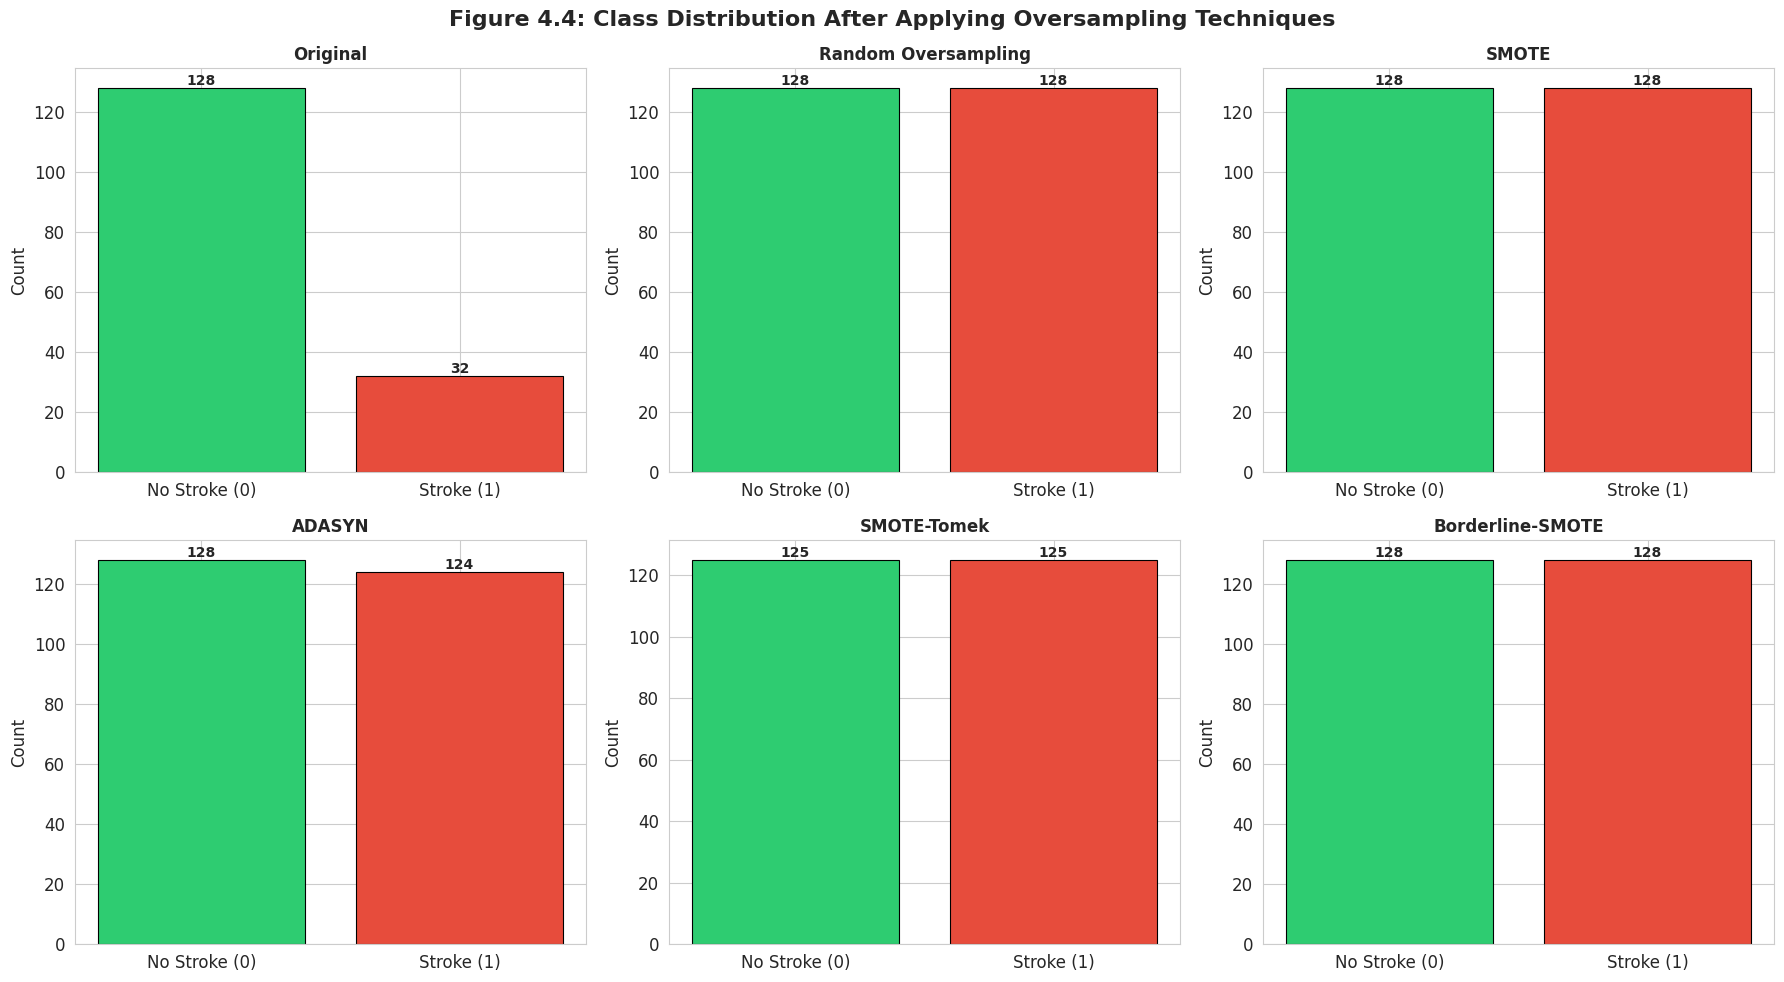

In [ ]:
# ============================================================
# Figure 4.4: Class Distribution After Applying Oversampling
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, counter) in enumerate(class_distributions.items()):
    ax = axes[idx]
    bars = ax.bar(['No Stroke (0)', 'Stroke (1)'],
                  [counter[0], counter[1]],
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, [counter[0], counter[1]]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Figure 4.4: Class Distribution After Applying Oversampling Techniques',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_4_4_oversampling_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Ensemble Learning Models (Section 3.6)

Eight models are implemented:

| # | Model | Type | Key Parameters |
|---|-------|------|----------------|
| 1 | Random Forest | Bagging | n_estimators=100 |
| 2 | XGBoost | Boosting | n_estimators=100, learning_rate=0.1 |
| 3 | LightGBM | Boosting | n_estimators=100, learning_rate=0.1 |
| 4 | CatBoost | Boosting | iterations=100, learning_rate=0.1 |
| 5 | Gradient Boosting | Boosting | n_estimators=100, learning_rate=0.1 |
| 6 | AdaBoost | Boosting | n_estimators=100, learning_rate=0.1 |
| 7 | Voting Classifier | Meta-Ensemble | Soft voting (RF, XGB, LGBM, CatBoost) |
| 8 | Stacking Classifier | Meta-Ensemble | Base: RF, XGB, LGBM; Meta: LogisticRegression |

In [ ]:
# ============================================================
# Section 3.6: Define Ensemble Learning Models
# ============================================================
print("=" * 60)
print("SECTION 3.6: ENSEMBLE LEARNING MODELS")
print("=" * 60)

def get_models():
    """Define and return all 8 ensemble models with configurations."""
    models = {}

    # 1. Random Forest (Bagging)
    models['Random Forest'] = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # 2. XGBoost (Gradient Boosting)
    models['XGBoost'] = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )

    # 3. LightGBM (Gradient Boosting)
    models['LightGBM'] = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )

    # 4. CatBoost (Gradient Boosting)
    models['CatBoost'] = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    )

    # 5. Gradient Boosting (sklearn)
    models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    # 6. AdaBoost
    models['AdaBoost'] = AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    # 7. Voting Classifier (Soft Voting Meta-Ensemble)
    models['Voting Classifier'] = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                                   use_label_encoder=False, eval_metric='logloss', verbosity=0)),
            ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)),
            ('catboost', CatBoostClassifier(iterations=100, learning_rate=0.1, random_state=42, verbose=0))
        ],
        voting='soft'
    )

    # 8. Stacking Classifier (Meta-Ensemble with Logistic Regression)
    models['Stacking Classifier'] = StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                                   use_label_encoder=False, eval_metric='logloss', verbosity=0)),
            ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1))
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=1000),
        cv=5
    )

    return models

# Display model configurations
models = get_models()
print(f"\nTotal models defined: {len(models)}")
for name, model in models.items():
    print(f"  ✅ {name}: {type(model).__name__}")

SECTION 3.6: ENSEMBLE LEARNING MODELS

Total models defined: 8
  ✅ Random Forest: RandomForestClassifier
  ✅ XGBoost: XGBClassifier
  ✅ LightGBM: LGBMClassifier
  ✅ CatBoost: CatBoostClassifier
  ✅ Gradient Boosting: GradientBoostingClassifier
  ✅ AdaBoost: AdaBoostClassifier
  ✅ Voting Classifier: VotingClassifier
  ✅ Stacking Classifier: StackingClassifier


In [ ]:
# ============================================================
# Table 3.2: Ensemble Learning Models and Configurations
# ============================================================
table_3_2 = pd.DataFrame([
    {'Model': 'Random Forest', 'Type': 'Bagging', 'Library': 'sklearn',
     'Key Parameters': 'n_estimators=100, random_state=42'},
    {'Model': 'XGBoost', 'Type': 'Boosting', 'Library': 'xgboost',
     'Key Parameters': 'n_estimators=100, learning_rate=0.1'},
    {'Model': 'LightGBM', 'Type': 'Boosting', 'Library': 'lightgbm',
     'Key Parameters': 'n_estimators=100, learning_rate=0.1'},
    {'Model': 'CatBoost', 'Type': 'Boosting', 'Library': 'catboost',
     'Key Parameters': 'iterations=100, learning_rate=0.1'},
    {'Model': 'Gradient Boosting', 'Type': 'Boosting', 'Library': 'sklearn',
     'Key Parameters': 'n_estimators=100, learning_rate=0.1'},
    {'Model': 'AdaBoost', 'Type': 'Boosting', 'Library': 'sklearn',
     'Key Parameters': 'n_estimators=100, learning_rate=0.1'},
    {'Model': 'Voting Classifier', 'Type': 'Meta-Ensemble', 'Library': 'sklearn',
     'Key Parameters': 'Soft voting: RF, XGB, LGBM, CatBoost'},
    {'Model': 'Stacking Classifier', 'Type': 'Meta-Ensemble', 'Library': 'sklearn',
     'Key Parameters': 'Base: RF, XGB, LGBM; Meta: LogisticRegression (cv=5)'},
])
print("Table 3.2: Ensemble Learning Models and Configurations")
table_3_2

Table 3.2: Ensemble Learning Models and Configurations


,Model,Type,Library,Key Parameters
0,Random Forest,Bagging,sklearn,"n_estimators=100, random_state=42"
1,XGBoost,Boosting,xgboost,"n_estimators=100, learning_rate=0.1"
2,LightGBM,Boosting,lightgbm,"n_estimators=100, learning_rate=0.1"
3,CatBoost,Boosting,catboost,"iterations=100, learning_rate=0.1"
4,Gradient Boosting,Boosting,sklearn,"n_estimators=100, learning_rate=0.1"
5,AdaBoost,Boosting,sklearn,"n_estimators=100, learning_rate=0.1"
6,Voting Classifier,Meta-Ensemble,sklearn,"Soft voting: RF, XGB, LGBM, CatBoost"
7,Stacking Classifier,Meta-Ensemble,sklearn,"Base: RF, XGB, LGBM; Meta: LogisticRegression ..."


---
## 7. Evaluation Metrics (Section 3.7)

Six metrics are used to comprehensively evaluate model performance:
1. **Accuracy** – Overall correctness
2. **Precision** – Positive predictive value
3. **Recall (Sensitivity)** – Most clinically important metric
4. **F1-Score** – Harmonic mean of precision and recall
5. **ROC-AUC** – Discrimination ability
6. **Average Precision** – Area under the precision-recall curve

In [ ]:
# ============================================================
# Section 3.7: Define Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained model using 6 metrics (Section 3.7).

    Parameters:
    -----------
    model : trained classifier
    X_test : test features
    y_test : test labels

    Returns:
    --------
    dict : dictionary containing all 6 evaluation metrics
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Avg Precision': average_precision_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

print("✅ Evaluation function defined with 6 metrics:")
print("   Accuracy, Precision, Recall, F1-Score, ROC-AUC, Average Precision")

✅ Evaluation function defined with 6 metrics:
   Accuracy, Precision, Recall, F1-Score, ROC-AUC, Average Precision


---
## 8. Full Experimental Pipeline (Section 3.8)

Execute all **48 combinations** (8 models × 6 sampling strategies).

**Environment:** Python 3.10, Google Colaboratory  
**Random Seed:** 42 (for reproducibility)

In [ ]:
# ============================================================
# Section 3.8: FULL EXPERIMENTAL PIPELINE
# 48 Combinations: 8 Models × 6 Sampling Techniques
# ============================================================
print("=" * 70)
print("SECTION 3.8: FULL EXPERIMENTAL PIPELINE")
print(f"Total Combinations: {len(oversampling_techniques)} sampling × {len(models)} models = {len(oversampling_techniques) * len(models)}")
print("=" * 70)

# Store all results
all_results = []
all_predictions = {}  # Store predictions for later visualizations

# Convert test set to numpy for consistent evaluation
X_test_np = X_test_scaled.values
y_test_np = y_test.values

total_experiments = len(oversampling_techniques) * len(get_models())
experiment_count = 0
start_time_total = time.time()

for sampling_name, (X_res, y_res) in resampled_datasets.items():
    print(f"\n{'─' * 50}")
    print(f"📊 Sampling Technique: {sampling_name}")
    print(f"   Training samples: {len(y_res)}")
    print(f"{'─' * 50}")

    # Re-create fresh models for each sampling technique
    fresh_models = get_models()

    for model_name, model in fresh_models.items():
        experiment_count += 1
        start_time = time.time()

        try:
            # Train the model
            model.fit(X_res, y_res)

            # Evaluate on the UNTOUCHED test set
            metrics, y_pred, y_prob = evaluate_model(model, X_test_np, y_test_np)

            elapsed = time.time() - start_time

            # Store results
            result = {
                'Sampling Technique': sampling_name,
                'Model': model_name,
                **metrics,
                'Training Time (s)': round(elapsed, 2)
            }
            all_results.append(result)

            # Store predictions for visualization
            key = f"{model_name}_{sampling_name}"
            all_predictions[key] = {
                'y_pred': y_pred,
                'y_prob': y_prob,
                'model_name': model_name,
                'sampling_name': sampling_name
            }

            print(f"  [{experiment_count}/{total_experiments}] {model_name}: "
                  f"F1={metrics['F1-Score']:.4f} | Recall={metrics['Recall']:.4f} | "
                  f"AUC={metrics['ROC-AUC']:.4f} | Time={elapsed:.1f}s")

        except Exception as e:
            print(f"  ❌ [{experiment_count}/{total_experiments}] {model_name}: ERROR - {str(e)}")
            result = {
                'Sampling Technique': sampling_name,
                'Model': model_name,
                'Accuracy': 0, 'Precision': 0, 'Recall': 0,
                'F1-Score': 0, 'ROC-AUC': 0, 'Avg Precision': 0,
                'Training Time (s)': 0
            }
            all_results.append(result)

total_elapsed = time.time() - start_time_total
print(f"\n{'=' * 70}")
print(f"✅ ALL {total_experiments} EXPERIMENTS COMPLETED IN {total_elapsed:.1f} SECONDS")
print(f"{'=' * 70}")

SECTION 3.8: FULL EXPERIMENTAL PIPELINE
Total Combinations: 6 sampling × 8 models = 48

──────────────────────────────────────────────────
📊 Sampling Technique: Original
   Training samples: 160
──────────────────────────────────────────────────
  [1/48] Random Forest: F1=0.4000 | Recall=0.2500 | AUC=0.6742 | Time=0.3s
  [2/48] XGBoost: F1=0.5000 | Recall=0.3750 | AUC=0.7273 | Time=0.1s
  [3/48] LightGBM: F1=0.3636 | Recall=0.2500 | AUC=0.7462 | Time=0.1s
  [4/48] CatBoost: F1=0.4000 | Recall=0.2500 | AUC=0.7159 | Time=0.2s
  [5/48] Gradient Boosting: F1=0.5455 | Recall=0.3750 | AUC=0.7500 | Time=0.2s
  [6/48] AdaBoost: F1=0.0000 | Recall=0.0000 | AUC=0.7595 | Time=0.3s
  [7/48] Voting Classifier: F1=0.3636 | Recall=0.2500 | AUC=0.7235 | Time=0.5s
  [8/48] Stacking Classifier: F1=0.2222 | Recall=0.1250 | AUC=0.7235 | Time=2.0s

──────────────────────────────────────────────────
📊 Sampling Technique: Random Oversampling
   Training samples: 256
──────────────────────────────────────────

In [ ]:
# ============================================================
# Table 4.3: Comparative Performance Results – ALL 48 Combinations
# ============================================================
results_df = pd.DataFrame(all_results)

# Format numeric columns
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Avg Precision']
results_display = results_df.copy()
for col in metric_cols:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}")

print("Table 4.3: Comparative Performance Results – All 48 Model-Sampling Combinations")
print(f"(8 Models × 6 Sampling Techniques = {len(results_df)} Total)\n")
results_display[['Sampling Technique', 'Model'] + metric_cols]

Table 4.3: Comparative Performance Results – All 48 Model-Sampling Combinations
(8 Models × 6 Sampling Techniques = 48 Total)



,Sampling Technique,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
0,Original,Random Forest,0.8537,1.0000,0.2500,0.4000,0.6742,0.4922
1,Original,XGBoost,0.8537,0.7500,0.3750,0.5000,0.7273,0.5487
2,Original,LightGBM,0.8293,0.6667,0.2500,0.3636,0.7462,0.4891
3,Original,CatBoost,0.8537,1.0000,0.2500,0.4000,0.7159,0.5002
4,Original,Gradient Boosting,0.8780,1.0000,0.3750,0.5455,0.7500,0.5792
5,Original,AdaBoost,0.8049,0.0000,0.0000,0.0000,0.7595,0.4435
6,Original,Voting Classifier,0.8293,0.6667,0.2500,0.3636,0.7235,0.5043
7,Original,Stacking Classifier,0.8293,1.0000,0.1250,0.2222,0.7235,0.5039
8,Random Oversampling,Random Forest,0.8049,0.5000,0.2500,0.3333,0.6610,0.4319
9,Random Oversampling,XGBoost,0.8049,0.5000,0.3750,0.4286,0.7462,0.5954


In [ ]:
# ============================================================
# Table 4.4: Performance Summary by Sampling Technique
# ============================================================
summary_by_sampling = results_df.groupby('Sampling Technique')[metric_cols].mean().round(4)
summary_by_sampling = summary_by_sampling.reindex(
    ['Original', 'Random Oversampling', 'SMOTE', 'ADASYN', 'SMOTE-Tomek', 'Borderline-SMOTE']
)
print("Table 4.4: Performance Summary by Sampling Technique (Averaged Across All Models)")
summary_by_sampling

Table 4.4: Performance Summary by Sampling Technique (Averaged Across All Models)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
Sampling Technique,,,,,,
Original,0.8415,0.7604,0.2344,0.3494,0.7275,0.5076
Random Oversampling,0.7927,0.5161,0.4062,0.4232,0.7261,0.4984
SMOTE,0.7805,0.4483,0.3281,0.3544,0.7405,0.4753
ADASYN,0.7652,0.4220,0.4219,0.4122,0.7507,0.5423
SMOTE-Tomek,0.7652,0.3858,0.3438,0.3466,0.7249,0.4494
Borderline-SMOTE,0.7774,0.4455,0.4219,0.4243,0.7041,0.5030


In [ ]:
# ============================================================
# Table 4.5: Performance Summary by Model
# ============================================================
summary_by_model = results_df.groupby('Model')[metric_cols].mean().round(4)
summary_by_model = summary_by_model.sort_values('F1-Score', ascending=False)
print("Table 4.5: Performance Summary by Model (Averaged Across All Sampling Techniques)")
summary_by_model

Table 4.5: Performance Summary by Model (Averaged Across All Sampling Techniques)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
Model,,,,,,
Gradient Boosting,0.8171,0.6065,0.4375,0.4859,0.7405,0.5341
XGBoost,0.8130,0.5417,0.3333,0.4100,0.7330,0.5373
AdaBoost,0.7033,0.2913,0.6042,0.3919,0.7677,0.4469
Voting Classifier,0.8008,0.5040,0.3125,0.3777,0.7260,0.5069
LightGBM,0.7967,0.4873,0.3125,0.3722,0.7247,0.5080
Random Forest,0.7886,0.5062,0.2917,0.3503,0.6973,0.4568
CatBoost,0.7724,0.4673,0.3125,0.3499,0.7191,0.4702
Stacking Classifier,0.8049,0.5667,0.2708,0.3423,0.7235,0.5081


In [ ]:
# ============================================================
# Table 4.6: Top 10 Best Model-Sampling Combinations by F1-Score
# ============================================================
top_10 = results_df.nlargest(10, 'F1-Score')[['Sampling Technique', 'Model'] + metric_cols].reset_index(drop=True)
top_10.index = top_10.index + 1  # Start ranking from 1
top_10.index.name = 'Rank'
for col in metric_cols:
    top_10[col] = top_10[col].apply(lambda x: f"{x:.4f}")
print("Table 4.6: Top 10 Best Model-Sampling Combinations by F1-Score")
top_10

Table 4.6: Top 10 Best Model-Sampling Combinations by F1-Score


,Sampling Technique,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
Rank,,,,,,,,
1,Original,Gradient Boosting,0.8780,1.0000,0.3750,0.5455,0.7500,0.5792
2,Original,XGBoost,0.8537,0.7500,0.3750,0.5000,0.7273,0.5487
3,Random Oversampling,Gradient Boosting,0.8537,0.7500,0.3750,0.5000,0.7727,0.5251
4,Random Oversampling,AdaBoost,0.6585,0.3500,0.8750,0.5000,0.7462,0.4488
5,SMOTE-Tomek,AdaBoost,0.7073,0.3750,0.7500,0.5000,0.7879,0.4655
6,Borderline-SMOTE,Gradient Boosting,0.8049,0.5000,0.5000,0.5000,0.6591,0.5417
7,SMOTE,AdaBoost,0.6829,0.3529,0.7500,0.4800,0.7879,0.4655
8,ADASYN,Gradient Boosting,0.7805,0.4444,0.5000,0.4706,0.7727,0.5881
9,SMOTE-Tomek,Gradient Boosting,0.7805,0.4444,0.5000,0.4706,0.7273,0.4412


---
## 9. Visualizations for Chapter 4

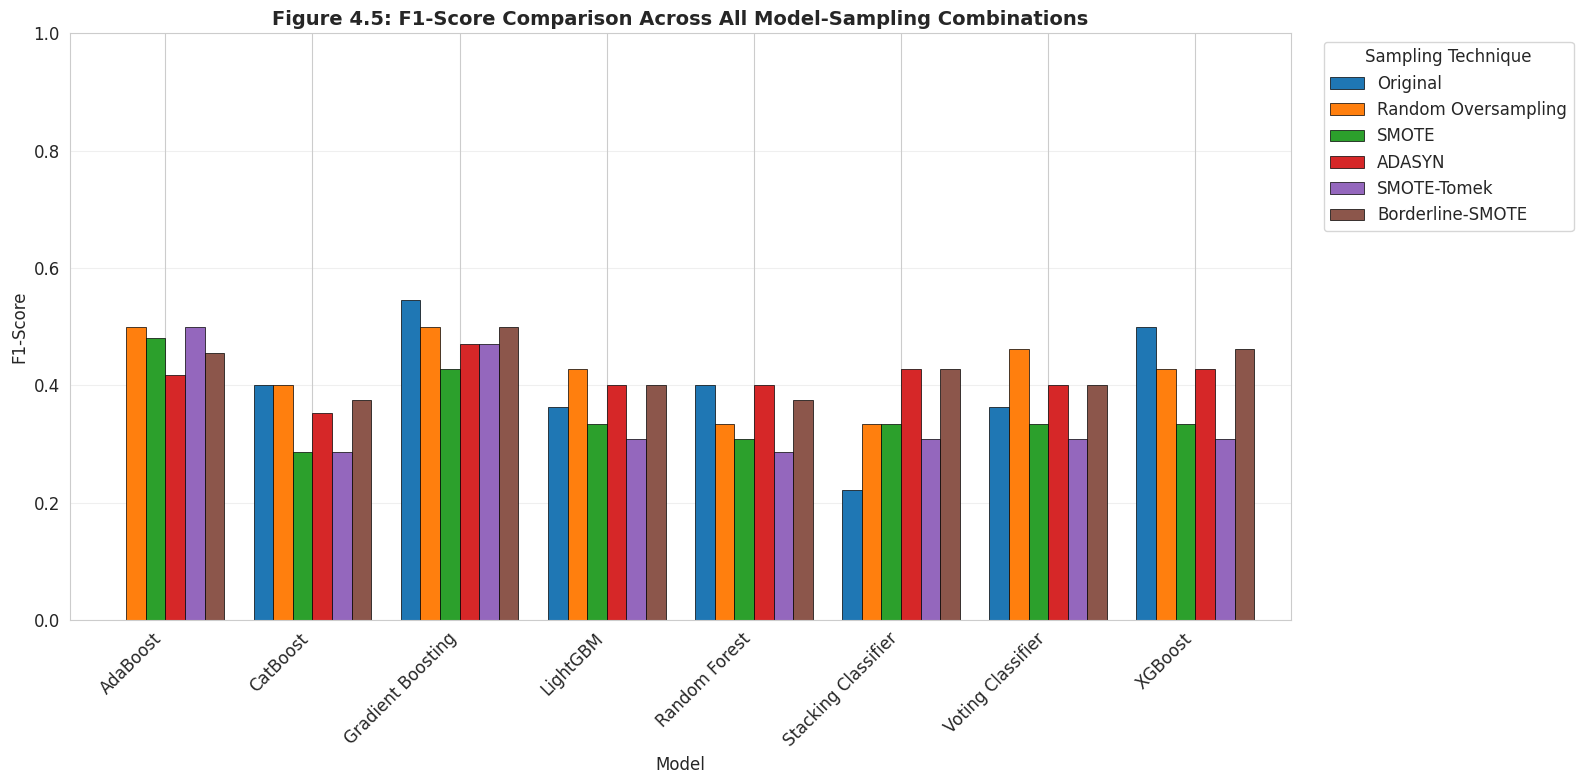

In [ ]:
# ============================================================
# Figure 4.5: F1-Score Comparison Across All Combinations
# ============================================================
pivot_f1 = results_df.pivot_table(
    values='F1-Score',
    index='Model',
    columns='Sampling Technique'
)

# Reorder columns
col_order = ['Original', 'Random Oversampling', 'SMOTE', 'ADASYN', 'SMOTE-Tomek', 'Borderline-SMOTE']
pivot_f1 = pivot_f1[col_order]

fig, ax = plt.subplots(figsize=(16, 8))
pivot_f1.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
ax.set_title('Figure 4.5: F1-Score Comparison Across All Model-Sampling Combinations',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(title='Sampling Technique', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_5_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

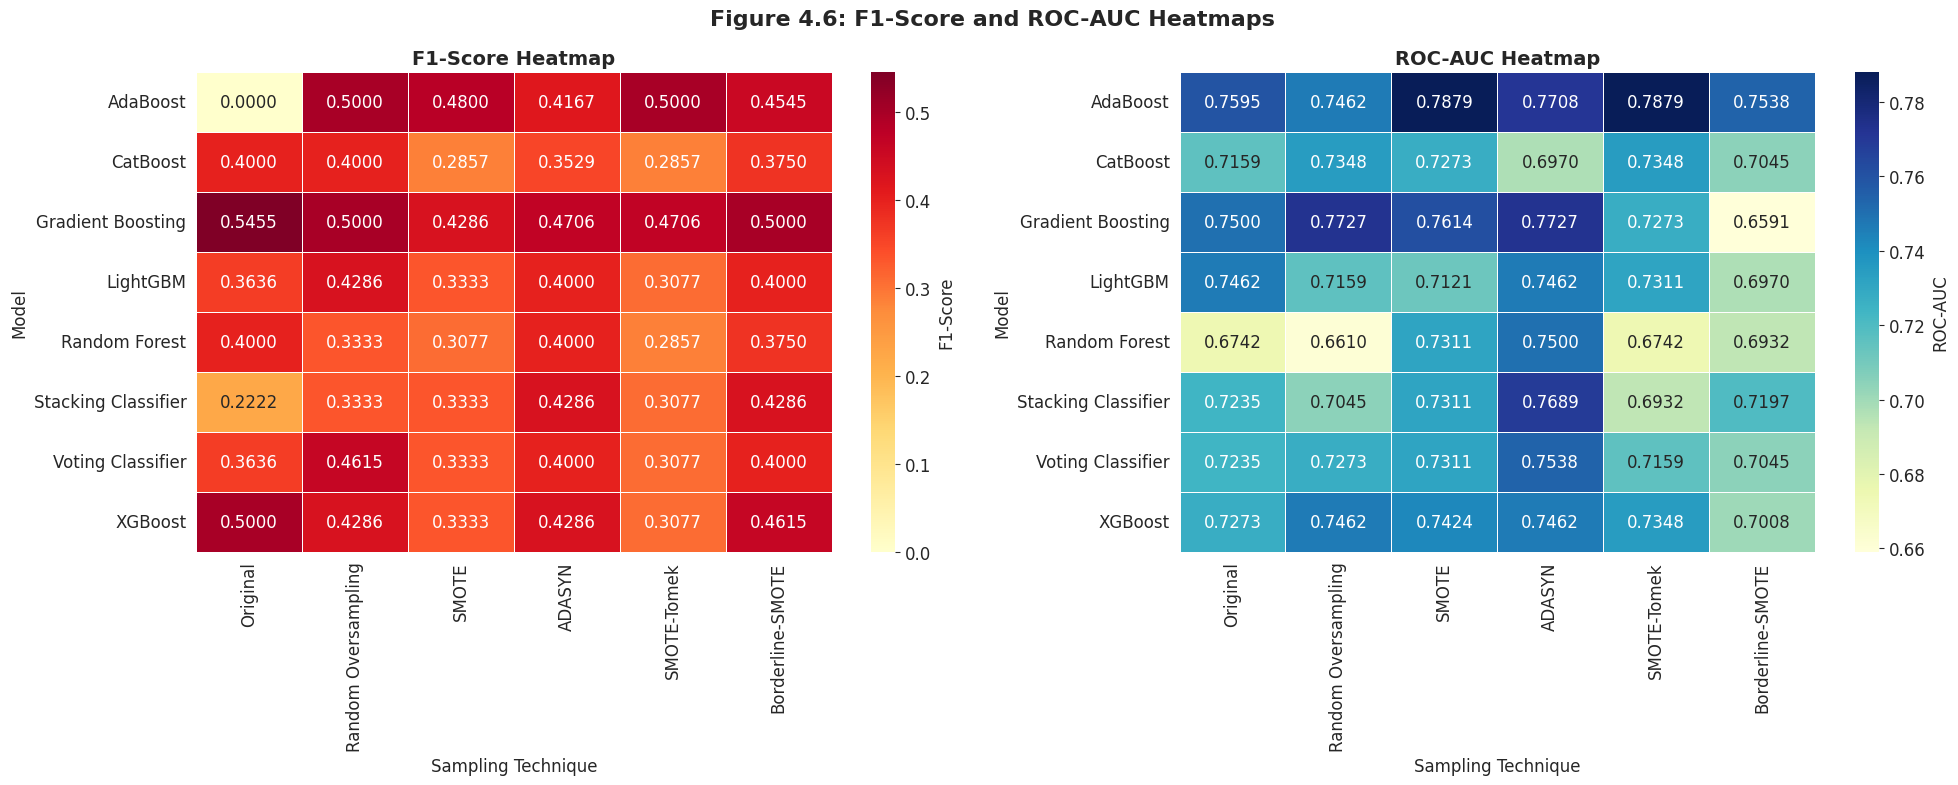

In [ ]:
# ============================================================
# Figure 4.6: F1-Score and ROC-AUC Heatmaps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# F1-Score Heatmap
pivot_f1_hm = results_df.pivot_table(values='F1-Score', index='Model', columns='Sampling Technique')
pivot_f1_hm = pivot_f1_hm[col_order]
sns.heatmap(pivot_f1_hm, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'F1-Score'})
axes[0].set_title('F1-Score Heatmap', fontsize=14, fontweight='bold')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ROC-AUC Heatmap
pivot_auc = results_df.pivot_table(values='ROC-AUC', index='Model', columns='Sampling Technique')
pivot_auc = pivot_auc[col_order]
sns.heatmap(pivot_auc, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'ROC-AUC'})
axes[1].set_title('ROC-AUC Heatmap', fontsize=14, fontweight='bold')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Figure 4.6: F1-Score and ROC-AUC Heatmaps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_4_6_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

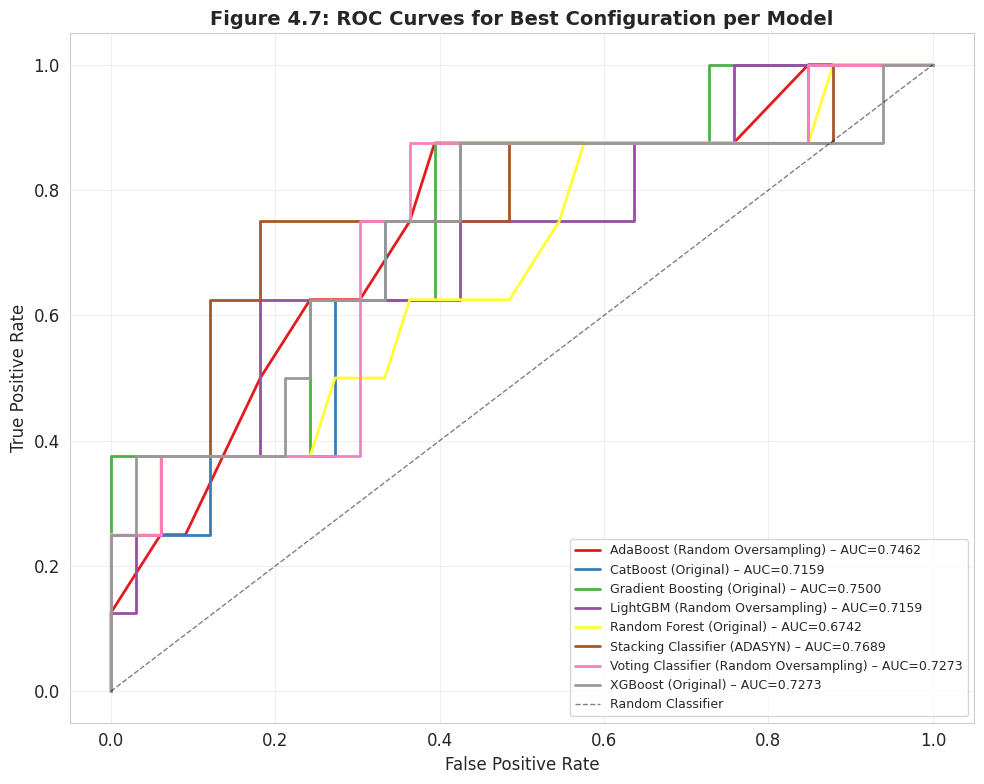

In [ ]:
# ============================================================
# Figure 4.7: ROC Curves for Best Configuration per Model
# ============================================================
# Find the best sampling technique for each model (by F1-Score)
best_configs = results_df.loc[results_df.groupby('Model')['F1-Score'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.Set1(np.linspace(0, 1, len(best_configs)))

for idx, (_, row) in enumerate(best_configs.iterrows()):
    key = f"{row['Model']}_{row['Sampling Technique']}"
    if key in all_predictions:
        y_prob = all_predictions[key]['y_prob']
        fpr, tpr, _ = roc_curve(y_test_np, y_prob)
        auc_val = roc_auc_score(y_test_np, y_prob)
        ax.plot(fpr, tpr, color=colors_roc[idx], linewidth=2,
                label=f"{row['Model']} ({row['Sampling Technique']}) – AUC={auc_val:.4f}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_title('Figure 4.7: ROC Curves for Best Configuration per Model',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_7_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

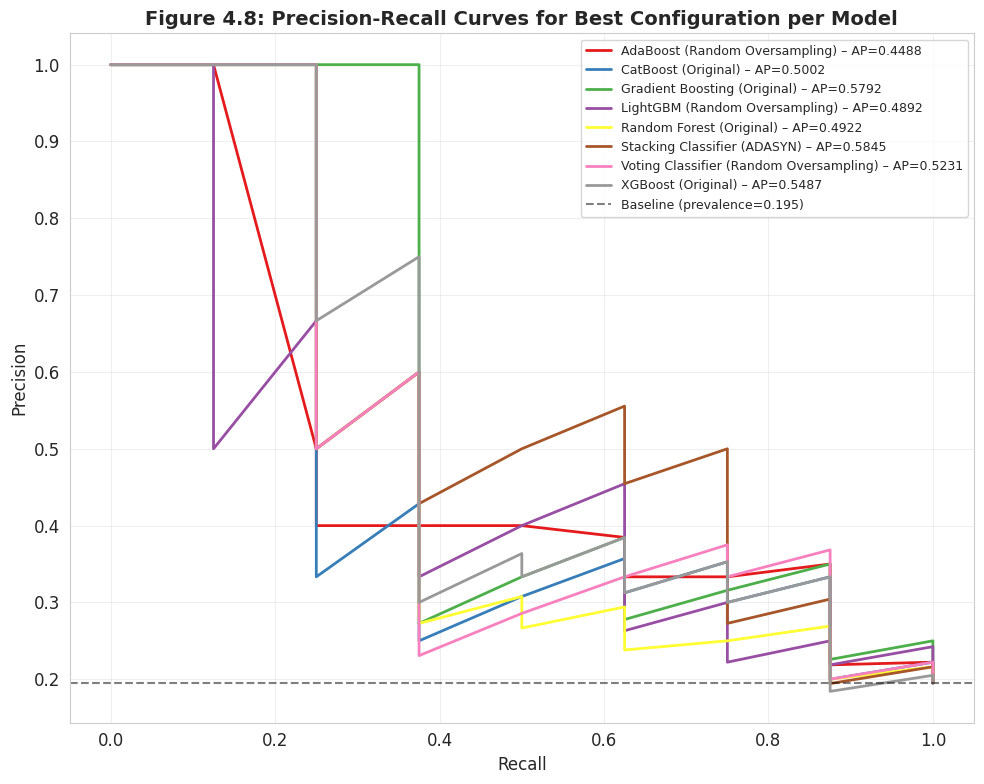

In [ ]:
# ============================================================
# Figure 4.8: Precision-Recall Curves for Best Configuration per Model
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (_, row) in enumerate(best_configs.iterrows()):
    key = f"{row['Model']}_{row['Sampling Technique']}"
    if key in all_predictions:
        y_prob = all_predictions[key]['y_prob']
        precision_curve, recall_curve, _ = precision_recall_curve(y_test_np, y_prob)
        ap_val = average_precision_score(y_test_np, y_prob)
        ax.plot(recall_curve, precision_curve, color=colors_roc[idx], linewidth=2,
                label=f"{row['Model']} ({row['Sampling Technique']}) – AP={ap_val:.4f}")

# Baseline
baseline = y_test_np.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.3f})')

ax.set_title('Figure 4.8: Precision-Recall Curves for Best Configuration per Model',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_4_8_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

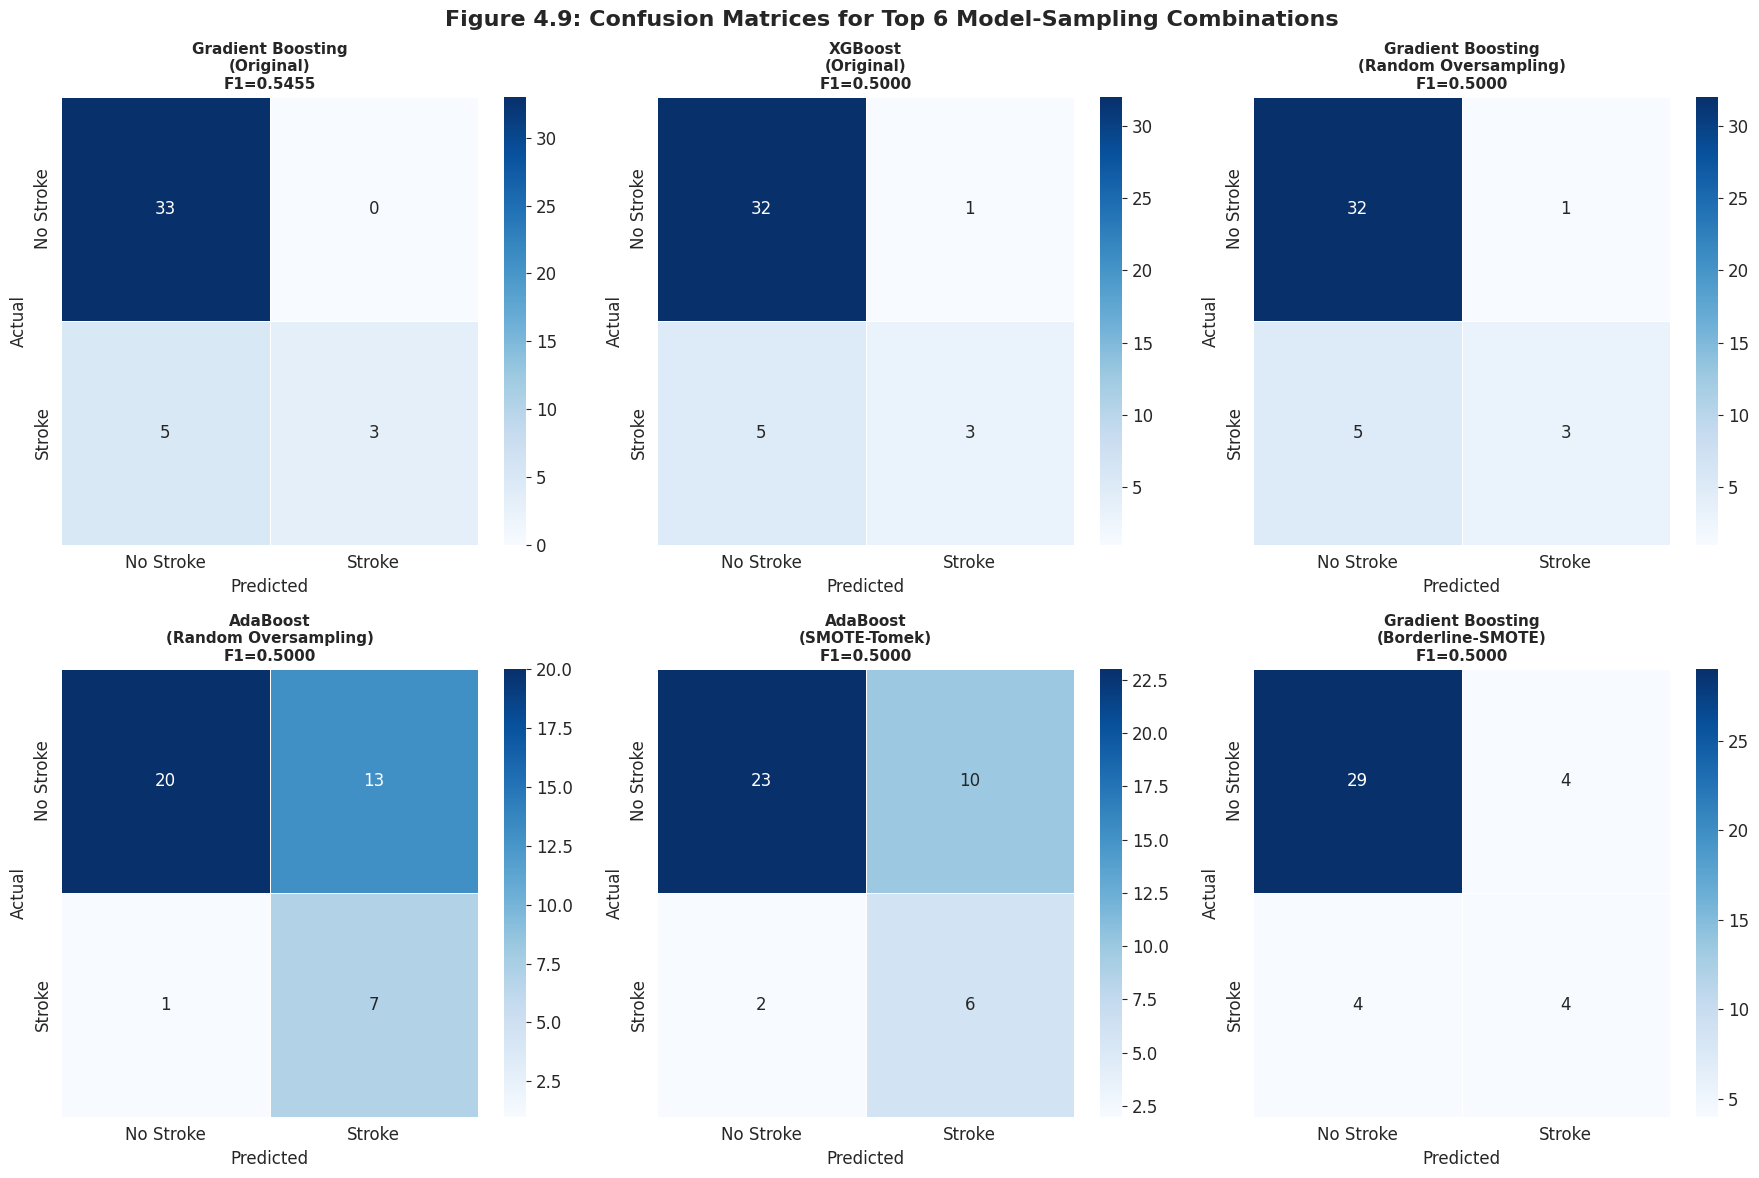

In [ ]:
# ============================================================
# Figure 4.9: Confusion Matrices for Top 6 Combinations
# ============================================================
top_6 = results_df.nlargest(6, 'F1-Score')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_6.iterrows()):
    key = f"{row['Model']}_{row['Sampling Technique']}"
    if key in all_predictions:
        y_pred = all_predictions[key]['y_pred']
        cm = confusion_matrix(y_test_np, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=['No Stroke', 'Stroke'],
                    yticklabels=['No Stroke', 'Stroke'],
                    linewidths=0.5)
        axes[idx].set_title(f"{row['Model']}\n({row['Sampling Technique']})\nF1={row['F1-Score']:.4f}",
                            fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Actual')
        axes[idx].set_xlabel('Predicted')

plt.suptitle('Figure 4.9: Confusion Matrices for Top 6 Model-Sampling Combinations',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_4_9_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 10. Export Results

In [ ]:
# ============================================================
# Export complete results to CSV
# ============================================================
results_df.to_csv('complete_results_48_combinations.csv', index=False)
summary_by_sampling.to_csv('summary_by_sampling_technique.csv')
summary_by_model.to_csv('summary_by_model.csv')

print("✅ Results exported:")
print("   📄 complete_results_48_combinations.csv")
print("   📄 summary_by_sampling_technique.csv")
print("   📄 summary_by_model.csv")

# Download results (uncomment for Colab)
# from google.colab import files
# files.download('complete_results_48_combinations.csv')
# files.download('summary_by_sampling_technique.csv')
# files.download('summary_by_model.csv')

✅ Results exported:
   📄 complete_results_48_combinations.csv
   📄 summary_by_sampling_technique.csv
   📄 summary_by_model.csv


In [ ]:
# ============================================================
# Final Summary
# ============================================================
print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"\nTotal combinations evaluated: {len(results_df)}")
print(f"Sampling techniques: {results_df['Sampling Technique'].nunique()}")
print(f"Models: {results_df['Model'].nunique()}")
print(f"\n{'─' * 70}")
print("BEST OVERALL COMBINATION (by F1-Score):")
print(f"{'─' * 70}")
best = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"  Model:              {best['Model']}")
print(f"  Sampling Technique: {best['Sampling Technique']}")
print(f"  Accuracy:           {best['Accuracy']:.4f}")
print(f"  Precision:          {best['Precision']:.4f}")
print(f"  Recall:             {best['Recall']:.4f}")
print(f"  F1-Score:           {best['F1-Score']:.4f}")
print(f"  ROC-AUC:            {best['ROC-AUC']:.4f}")
print(f"  Avg Precision:      {best['Avg Precision']:.4f}")

print(f"\n{'─' * 70}")
print("BEST COMBINATION (by Recall – Clinical Priority):")
print(f"{'─' * 70}")
best_recall = results_df.loc[results_df['Recall'].idxmax()]
print(f"  Model:              {best_recall['Model']}")
print(f"  Sampling Technique: {best_recall['Sampling Technique']}")
print(f"  Recall:             {best_recall['Recall']:.4f}")
print(f"  F1-Score:           {best_recall['F1-Score']:.4f}")

EXPERIMENT SUMMARY

Total combinations evaluated: 48
Sampling techniques: 6
Models: 8

──────────────────────────────────────────────────────────────────────
BEST OVERALL COMBINATION (by F1-Score):
──────────────────────────────────────────────────────────────────────
  Model:              Gradient Boosting
  Sampling Technique: Original
  Accuracy:           0.8780
  Precision:          1.0000
  Recall:             0.3750
  F1-Score:           0.5455
  ROC-AUC:            0.7500
  Avg Precision:      0.5792

──────────────────────────────────────────────────────────────────────
BEST COMBINATION (by Recall – Clinical Priority):
──────────────────────────────────────────────────────────────────────
  Model:              AdaBoost
  Sampling Technique: Random Oversampling
  Recall:             0.8750
  F1-Score:           0.5000


In [ ]:
# ============================================================
# Figure 3.1: Research Methodology Flowchart (Text Summary)
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════╗
║         FIGURE 3.1: RESEARCH METHODOLOGY FLOWCHART             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  [1] DATASET LOADING                                           ║
║      └─ Kaggle Stroke Prediction Dataset (5,110 records)       ║
║                          ↓                                     ║
║  [2] DATA PREPROCESSING                                       ║
║      ├─ Missing value imputation (BMI → median)                ║
║      ├─ Label Encoding (categorical features)                  ║
║      └─ StandardScaler (numerical features)                    ║
║                          ↓                                     ║
║  [3] TRAIN-TEST SPLIT                                          ║
║      └─ 80/20 Stratified Split (random_state=42)               ║
║                          ↓                                     ║
║  [4] OVERSAMPLING (Training Set Only)                          ║
║      ├─ Original (No Sampling)                                 ║
║      ├─ Random Oversampling                                    ║
║      ├─ SMOTE (k=5)                                            ║
║      ├─ ADASYN                                                 ║
║      ├─ SMOTE-Tomek Links                                      ║
║      └─ Borderline-SMOTE                                       ║
║                          ↓                                     ║
║  [5] MODEL TRAINING (8 Ensemble Models × 6 Techniques)         ║
║      ├─ Random Forest         ├─ Gradient Boosting             ║
║      ├─ XGBoost               ├─ AdaBoost                      ║
║      ├─ LightGBM              ├─ Voting Classifier             ║
║      └─ CatBoost              └─ Stacking Classifier           ║
║                          ↓                                     ║
║  [6] EVALUATION (6 Metrics on Untouched Test Set)              ║
║      ├─ Accuracy    ├─ Recall       ├─ ROC-AUC                 ║
║      ├─ Precision   ├─ F1-Score     └─ Average Precision       ║
║                          ↓                                     ║
║  [7] COMPARATIVE ANALYSIS & RESULTS                            ║
║      └─ 48 Total Combinations Evaluated                        ║
║                                                                ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         FIGURE 3.1: RESEARCH METHODOLOGY FLOWCHART             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                ║
║  [1] DATASET LOADING                                           ║
║      └─ Kaggle Stroke Prediction Dataset (5,110 records)       ║
║                          ↓                                     ║
║  [2] DATA PREPROCESSING                                       ║
║      ├─ Missing value imputation (BMI → median)                ║
║      ├─ Label Encoding (categorical features)                  ║
║      └─ StandardScaler (numerical features)                    ║
║                          ↓                                     ║
║  [3] TRAIN-TEST SPLIT                                          ║
║      └─ 80/20 Stratified Split (random_state=42)               ║
║                          ↓                              